# Objective

The objective of this project is to build a machine learning model that predicts whether a passenger was satisfied or dissatisfied with their overall travel experience on the Shinkansen Bullet Train in Japan. The analysis combines operational travel data and passenger survey responses to identify the key factors that influence customer satisfaction. By examining variables such as seat comfort, onboard services, cleanliness, delays, catering, and online services, the study aims to determine the relative importance of each feature in shaping passengers’ perceptions and overall experience.



# Loading the libraries and data

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn import model_selection
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
import warnings
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dense, Input, Dropout,BatchNormalization
from scikeras.wrappers import KerasClassifier
from sklearn.preprocessing import StandardScaler
import random
from tensorflow.keras import backend
random.seed(1)
np.random.seed(1)
tf.random.set_seed(1)
warnings.filterwarnings("ignore")

In [2]:

data_train = pd.read_csv('Traveldata_train_(1)_(1).csv')
data_test=pd.read_csv('Traveldata_test_(1)_(1).csv')

In [3]:
surv_train=pd.read_csv('Surveydata_train_(1)_(1).csv')
surv_test=pd.read_csv('Surveydata_test_(1)_(1).csv')


Checking the column information


In [4]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94379 entries, 0 to 94378
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       94379 non-null  int64  
 1   Gender                   94302 non-null  object 
 2   Customer_Type            85428 non-null  object 
 3   Age                      94346 non-null  float64
 4   Type_Travel              85153 non-null  object 
 5   Travel_Class             94379 non-null  object 
 6   Travel_Distance          94379 non-null  int64  
 7   Departure_Delay_in_Mins  94322 non-null  float64
 8   Arrival_Delay_in_Mins    94022 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 6.5+ MB


In [5]:
surv_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94379 entries, 0 to 94378
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ID                       94379 non-null  int64 
 1   Overall_Experience       94379 non-null  int64 
 2   Seat_Comfort             94318 non-null  object
 3   Seat_Class               94379 non-null  object
 4   Arrival_Time_Convenient  85449 non-null  object
 5   Catering                 85638 non-null  object
 6   Platform_Location        94349 non-null  object
 7   Onboard_Wifi_Service     94349 non-null  object
 8   Onboard_Entertainment    94361 non-null  object
 9   Online_Support           94288 non-null  object
 10  Ease_of_Online_Booking   94306 non-null  object
 11  Onboard_Service          86778 non-null  object
 12  Legroom                  94289 non-null  object
 13  Baggage_Handling         94237 non-null  object
 14  CheckIn_Service          94302 non-nul

Create one dataset for training and one for testing by merging the dataframes

In [6]:

df=pd.merge(surv_train,data_train,on='ID')
df_test=pd.merge(surv_test,data_test,on='ID')

 `df.info()` shows that there are missing data in some columns

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94379 entries, 0 to 94378
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       94379 non-null  int64  
 1   Overall_Experience       94379 non-null  int64  
 2   Seat_Comfort             94318 non-null  object 
 3   Seat_Class               94379 non-null  object 
 4   Arrival_Time_Convenient  85449 non-null  object 
 5   Catering                 85638 non-null  object 
 6   Platform_Location        94349 non-null  object 
 7   Onboard_Wifi_Service     94349 non-null  object 
 8   Onboard_Entertainment    94361 non-null  object 
 9   Online_Support           94288 non-null  object 
 10  Ease_of_Online_Booking   94306 non-null  object 
 11  Onboard_Service          86778 non-null  object 
 12  Legroom                  94289 non-null  object 
 13  Baggage_Handling         94237 non-null  object 
 14  CheckIn_Service       

Also we Distinguish that some columns contain categorical data 

In [8]:
categorical_cols = [
    'Seat_Comfort', 'Arrival_Time_Convenient', 'Catering',
    'Platform_Location', 'Onboard_Wifi_Service', 'Onboard_Entertainment',
    'Online_Support', 'Ease_of_Online_Booking', 'Onboard_Service',
    'Legroom', 'Baggage_Handling', 'CheckIn_Service', 'Cleanliness',
    'Online_Boarding', 'Gender', 'Customer_Type', 'Type_Travel', 'Seat_Class'
]

while some other numerical data


In [9]:
numeric_cols = ['Age', 'Departure_Delay_in_Mins', 'Arrival_Delay_in_Mins']


Checking for dublicates

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df_test.duplicated().sum()

np.int64(0)

In [12]:
for i in df.describe(include=["object"]).columns:
    print("Unique values in", i, "are :")
    print(df[i].value_counts())
    print("*" * 50)

Unique values in Seat_Comfort are :
Seat_Comfort
Acceptable           21158
Needs Improvement    20946
Good                 20595
Poor                 15185
Excellent            12971
Extremely Poor        3463
Name: count, dtype: int64
**************************************************
Unique values in Seat_Class are :
Seat_Class
Green Car    47435
Ordinary     46944
Name: count, dtype: int64
**************************************************
Unique values in Arrival_Time_Convenient are :
Arrival_Time_Convenient
Good                 19574
Excellent            17684
Acceptable           15177
Needs Improvement    14990
Poor                 13692
Extremely Poor        4332
Name: count, dtype: int64
**************************************************
Unique values in Catering are :
Catering
Acceptable           18468
Needs Improvement    17978
Good                 17969
Poor                 13858
Excellent            13455
Extremely Poor        3910
Name: count, dtype: int64
*************

In [80]:
for i in df_test.describe(include=["object"]).columns:
    print("Unique values in", i, "are :")
    print(df[i].value_counts())
    print("*" * 50)

Unique values in Seat_Comfort are :
Seat_Comfort
Acceptable           21158
Needs Improvement    20946
Good                 20595
Poor                 15185
Excellent            12971
Extremely Poor        3463
Name: count, dtype: int64
**************************************************
Unique values in Seat_Class are :
Seat_Class
Green Car    47435
Ordinary     46944
Name: count, dtype: int64
**************************************************
Unique values in Arrival_Time_Convenient are :
Arrival_Time_Convenient
Good                 19574
Excellent            17684
Acceptable           15177
Needs Improvement    14990
Poor                 13692
Extremely Poor        4332
Name: count, dtype: int64
**************************************************
Unique values in Catering are :
Catering
Acceptable           18468
Needs Improvement    17978
Good                 17969
Poor                 13858
Excellent            13455
Extremely Poor        3910
Name: count, dtype: int64
*************

Below we can see that the target column is well balanced in train and test data 

In [13]:
print(df['Overall_Experience'].unique())
print(df['Overall_Experience'].value_counts())


[0 1]
Overall_Experience
1    51593
0    42786
Name: count, dtype: int64


Working on missing data
replace the missing in numerical columns with median while in categorical columns with mode

In [14]:
#df.isnull().sum()
df_test.isnull().sum()

ID                            0
Seat_Comfort                 22
Seat_Class                    0
Arrival_Time_Convenient    3325
Catering                   3357
Platform_Location            12
Onboard_Wifi_Service         12
Onboard_Entertainment         8
Online_Support               26
Ease_of_Online_Booking       18
Onboard_Service            2872
Legroom                      25
Baggage_Handling             40
CheckIn_Service              22
Cleanliness                   2
Online_Boarding               2
Gender                       30
Customer_Type              3383
Age                          11
Type_Travel                3448
Travel_Class                  0
Travel_Distance               0
Departure_Delay_in_Mins      29
Arrival_Delay_in_Mins       123
dtype: int64

# MANAGE MISSING DATA

In [15]:
# ===== TARGET VARIABLE EXTRACTION =====
# Extract target AFTER encoding to avoid conflicts
y = df['Overall_Experience']

# ===== STEP 4: FEATURE EXTRACTION =====
# NOW extract features - both have been properly encoded
X = df.drop(['Overall_Experience'], axis=1)



# ===== MANAGE MISSING DATA=====


# Numerical columns
numerical_features = X.select_dtypes(include=['float64', 'int64']).columns

num_imputer = SimpleImputer(strategy='median')

X[numerical_features] = num_imputer.fit_transform(X[numerical_features])
df_test[numerical_features] = num_imputer.transform(df_test[numerical_features])
# Categorical columns
categorical_features = df.select_dtypes(include=['object']).columns

cat_imputer = SimpleImputer(strategy='most_frequent')

df[categorical_features] = cat_imputer.fit_transform(df[categorical_features])
df_test[categorical_features] = cat_imputer.transform(df_test[categorical_features])

In [16]:
#check whether it worked correctly
df.isnull().sum()

ID                           0
Overall_Experience           0
Seat_Comfort                 0
Seat_Class                   0
Arrival_Time_Convenient      0
Catering                     0
Platform_Location            0
Onboard_Wifi_Service         0
Onboard_Entertainment        0
Online_Support               0
Ease_of_Online_Booking       0
Onboard_Service              0
Legroom                      0
Baggage_Handling             0
CheckIn_Service              0
Cleanliness                  0
Online_Boarding              0
Gender                       0
Customer_Type                0
Age                         33
Type_Travel                  0
Travel_Class                 0
Travel_Distance              0
Departure_Delay_in_Mins     57
Arrival_Delay_in_Mins      357
dtype: int64

# Encoding categorical data

In [17]:


# ===== ONE-HOT ENCODING =====
# Encode BOTH datasets BEFORE creating X and X_test
# This ensures all one-hot columns exist in both datasets
X = pd.get_dummies(
    X,
    columns=list(X.select_dtypes(include=['object']).columns),
    drop_first=False
)
df_test = pd.get_dummies(
    df_test,
    columns=list(df_test.select_dtypes(include=['object']).columns),
    drop_first=False
)
# CRITICAL FIX: Assign X_test AFTER encoding
# Now X_test will have bool dtypes matching X
X_test = df_test.copy()  # Use .copy() to avoid SettingWithCopyWarning

# ===== COLUMN ALIGNMENT =====
# Add missing one-hot columns that exist in training but not in test
# (This happens when test data lacks certain categories)
missing_columns = [
    'CheckIn_Service_Extremely Poor',
    'Cleanliness_Extremely Poor',
    'Onboard_Service_Extremely Poor',
    'Online_Support_Extremely Poor',
    'Platform_Location_Very Inconvenient'
]

# Add as 0s (test data has no samples with these categories)
for col in missing_columns:
    if col not in X_test.columns:
        X_test[col] = 0

# Reorder X_test columns to exactly match X
# This is CRITICAL for neural networks - feature order must be consistent
X_test = X_test[X.columns]

# ===== VERIFICATION =====
# Analytical checks to ensure data consistency
print("\n=== DATA CONSISTENCY CHECKS ===")
print(f"X shape: {X.shape}, X_test shape: {X_test.shape}")
print(f"Feature count match: {X.shape[1] == X_test.shape[1]}")

# Check dtypes match
print(f"\nX dtype summary: {X.dtypes.value_counts()}")
print(f"X_test dtype summary: {X_test.dtypes.value_counts()}")
print(f"Data types identical: {X.dtypes.equals(X_test.dtypes)}")

# Check column order matches
print(f"\nColumn order match: {list(X.columns) == list(X_test.columns)}")

# Verify no NaN values remain
print(f"X NaN count: {X.isna().sum().sum()}")
print(f"X_test NaN count: {X_test.isna().sum().sum()}")


=== DATA CONSISTENCY CHECKS ===
X shape: (94379, 98), X_test shape: (35602, 98)
Feature count match: True

X dtype summary: bool       93
float64     5
Name: count, dtype: int64
X_test dtype summary: bool       88
float64     5
int64       5
Name: count, dtype: int64
Data types identical: False

Column order match: True
X NaN count: 0
X_test NaN count: 0


Test which are the unique values

In [18]:
df.nunique()

ID                         94379
Overall_Experience             2
Seat_Comfort                   6
Seat_Class                     2
Arrival_Time_Convenient        6
Catering                       6
Platform_Location              6
Onboard_Wifi_Service           6
Onboard_Entertainment          6
Online_Support                 6
Ease_of_Online_Booking         6
Onboard_Service                6
Legroom                        6
Baggage_Handling               5
CheckIn_Service                6
Cleanliness                    6
Online_Boarding                6
Gender                         2
Customer_Type                  2
Age                           75
Type_Travel                    2
Travel_Class                   2
Travel_Distance             5210
Departure_Delay_in_Mins      437
Arrival_Delay_in_Mins        434
dtype: int64

In [19]:

df_test.nunique()

ID                              35602
Age                                75
Travel_Distance                  4644
Departure_Delay_in_Mins           350
Arrival_Delay_in_Mins             355
                                ...  
Customer_Type_Loyal Customer        2
Type_Travel_Business Travel         2
Type_Travel_Personal Travel         2
Travel_Class_Business               2
Travel_Class_Eco                    2
Length: 93, dtype: int64

From the above we can drop the ID column

In [20]:
X.drop(columns="ID", inplace=True)

In [36]:
X_test.drop(columns="ID", inplace=True)

In [21]:
categorical_features = X.select_dtypes(include='object').columns.tolist()
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Numeric features ({len(numeric_features)}): {numeric_features}")



Categorical features (0): []
Numeric features (4): ['Age', 'Travel_Distance', 'Departure_Delay_in_Mins', 'Arrival_Delay_in_Mins']


No categorical features in the training dataset because we implemented one hot encoding earlier. In the test set there are some columns that are excluded from one hot encoding because they did not exist in the dataset

# Scaling the data with StandarScaler

In [22]:
# ===== SCALING STRATEGY =====
# Key Principle: Scaler is fit ONLY on training data
# Test data is transformed using training statistics
# This mimics production: fit scaler on historical training, 
# apply to new incoming data

numeric_features = ['Age', 'Departure_Delay_in_Mins', 'Arrival_Delay_in_Mins']
                   # (ID and Travel_Distance are removed earlier)

# ===== STEP 1: FIT SCALER ON TRAINING DATA ONLY =====
scaler = StandardScaler()

# fit_transform: Learn mean/std from X, then scale X
X[numeric_features] = scaler.fit_transform(X[numeric_features])

print("Scaler fitted on training data:")
print(f"  Mean values: {scaler.mean_}")
print(f"  Std values: {scaler.scale_}")

# ===== STEP 2: TRANSFORM TEST DATA USING TRAINING STATISTICS =====
# Use ONLY .transform() - this uses scaler.mean_ and scaler.scale_
# learned from training data
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

print("\nTest data transformed using training statistics (no refitting)")
print("  This prevents data leakage and ensures honest evaluation")





Scaler fitted on training data:
  Mean values: [39.41984975 14.6382458  14.94846311]
  Std values: [15.11391262 38.12875861 38.3774912 ]

Test data transformed using training statistics (no refitting)
  This prevents data leakage and ensures honest evaluation


In [23]:
X.shape

(94379, 97)

In [24]:
X_test.shape

(35602, 98)

# Initializing the ANN

In [25]:
backend.clear_session()
#Fixing the seed for random number generators so that we can ensure we receive the same output everytime
np.random.seed(42)
import random
random.seed(42)
tf.random.set_seed(42)

# Model 1

In [26]:

input_dim = X.shape[1]
input_dim

97

Hidden layers 128->64->32->16
Binary classification-> a sigmoid activation function in the end

Binary classification problem-> using binary_crossentropy loss function. As an estimator using Adam

Create a 20% validation dataset. Run the ANN for 50 epochs with 32 batch size

Plot the loss function vs epochs for train and validation dataset 

In [58]:
model2=Sequential()
model2 = Sequential([
    Dense(128, activation='relu', input_dim=input_dim),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [59]:
model2.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [60]:
history2=model2.fit(X, y,
          validation_split=0.2,
          epochs=50,
          batch_size=32,verbose=1)

Epoch 1/50
2360/2360 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7927 - loss: 0.5811 - val_accuracy: 0.8529 - val_loss: 0.3489
Epoch 2/50
2360/2360 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8597 - loss: 0.3377 - val_accuracy: 0.8876 - val_loss: 0.2728
Epoch 3/50
2360/2360 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8749 - loss: 0.3015 - val_accuracy: 0.8969 - val_loss: 0.2512
Epoch 4/50
2360/2360 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8831 - loss: 0.2829 - val_accuracy: 0.8930 - val_loss: 0.2599
Epoch 5/50
2360/2360 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8870 - loss: 0.2710 - val_accuracy: 0.8996 - val_loss: 0.2437
Epoch 6/50
2360/2360 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8914 - loss: 0.2603 - val_accuracy: 0.8950 - val_loss: 0.2484
Epoch 7/50
2360/2360 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8934 - loss: 0.2521 - val_accuracy: 0.8587 - val_loss: 0.3496
Epoch 8/50
2360/2360 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8954 - loss: 0.2437 - 

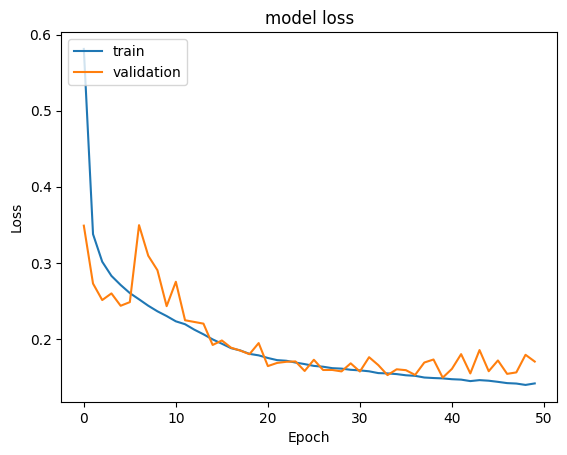

In [61]:
#Plotting Train Loss vs Validation Loss
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

This is  a good training curve overall.


Training loss decreases smoothly and consistently
Validation loss decreases too
Around epochs 20–35 both curves are very close
Small fluctuations after epoch 35 are normal
Only mild overfitting appears near the en

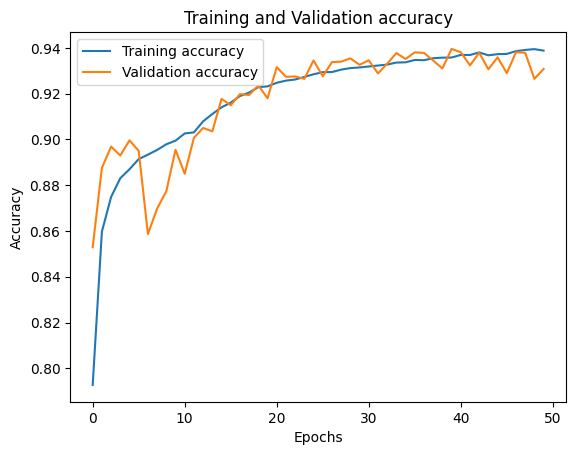

In [62]:
history_df = pd.DataFrame(history2.history)

plt.plot(history_df.loc[:, ['accuracy']], label='Training accuracy')
plt.plot(history_df.loc[:, ['val_accuracy']], label='Validation accuracy')

plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [63]:
val_accuracy = np.mean(history2.history['val_accuracy'])
print("\n%s: %.2f%%" % ('val_accuracy', val_accuracy*100))


val_accuracy: 91.86%


In [65]:
# ===== PREDICTIONS SECTION =====
# CRITICAL: Use the most recently trained and best-performing model

print("\n" + "="*70)
print("MODEL PREDICTION PHASE")
print("="*70)
print(f"\nUsing: model_optimized")
print(f"  - Architecture: {model2.count_params()} parameters")
print(f"  - Validation accuracy achieved: {max(history2.history['val_accuracy']):.4f}")

# ===== GENERATE PREDICTIONS =====
# Use .predict() on test set with optimized model
y_pred_prob = model2.predict(X_test)

# Convert probabilities to binary predictions
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print(f"\nPredictions generated:")
print(f"  - Total samples: {len(y_pred)}")
print(f"  - Predicted as Dissatisfied (0): {(y_pred == 0).sum()}")
print(f"  - Predicted as Satisfied (1): {(y_pred == 1).sum()}")
print(f"  - Class 1 percentage: {(y_pred == 1).sum() / len(y_pred) * 100:.1f}%")

# ===== OPTIONAL: DETAILED PREDICTION ANALYSIS =====
# If you have true test labels (y_test):
if 'y_test' in locals():
    from sklearn.metrics import confusion_matrix, classification_report
    
    print("\n" + "="*70)
    print("PREDICTION QUALITY ANALYSIS")
    print("="*70)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\nConfusion Matrix:")
    print(f"  True Negatives:  {cm[0,0]}")
    print(f"  False Positives: {cm[0,1]}")
    print(f"  False Negatives: {cm[1,0]}")
    print(f"  True Positives:  {cm[1,1]}")
    
    # Detailed metrics
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Overall accuracy
    accuracy = (y_pred == y_test).sum() / len(y_test)
    print(f"\nTest Accuracy: {accuracy:.4f}")


MODEL PREDICTION PHASE

Using: model_optimized
  - Architecture: 23425 parameters
  - Validation accuracy achieved: 0.9396
1113/1113 ━━━━━━━━━━━━━━━━━━━━ 1s 461us/step

Predictions generated:
  - Total samples: 35602
  - Predicted as Dissatisfied (0): 15071
  - Predicted as Satisfied (1): 20531
  - Class 1 percentage: 57.7%


# Model 2 Reduce Model Complexity-Less layers

Dense(64) → Dense(32) → Dense(1)


In [33]:
model3=Sequential()
model3 = Sequential([
    Dense(64, activation='relu', input_dim=input_dim),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [34]:
model3.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [35]:
history3=model3.fit(X, y,
          validation_split=0.2,
          epochs=50,
          batch_size=32,verbose=1)

Epoch 1/50
2360/2360 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8008 - loss: 0.9058 - val_accuracy: 0.8477 - val_loss: 0.3902
Epoch 2/50
2360/2360 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8544 - loss: 0.4051 - val_accuracy: 0.8934 - val_loss: 0.2666
Epoch 3/50
2360/2360 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8679 - loss: 0.3357 - val_accuracy: 0.8992 - val_loss: 0.2494
Epoch 4/50
2360/2360 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8760 - loss: 0.3125 - val_accuracy: 0.8935 - val_loss: 0.2646
Epoch 5/50
2360/2360 ━━━━━━━━━━━━━━━━━━━━ 2s 987us/step - accuracy: 0.8813 - loss: 0.2937 - val_accuracy: 0.8999 - val_loss: 0.2436
Epoch 6/50
2360/2360 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8851 - loss: 0.2812 - val_accuracy: 0.8990 - val_loss: 0.2474
Epoch 7/50
2360/2360 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8872 - loss: 0.2763 - val_accuracy: 0.8989 - val_loss: 0.2456
Epoch 8/50
2360/2360 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8905 - loss: 0.2635 

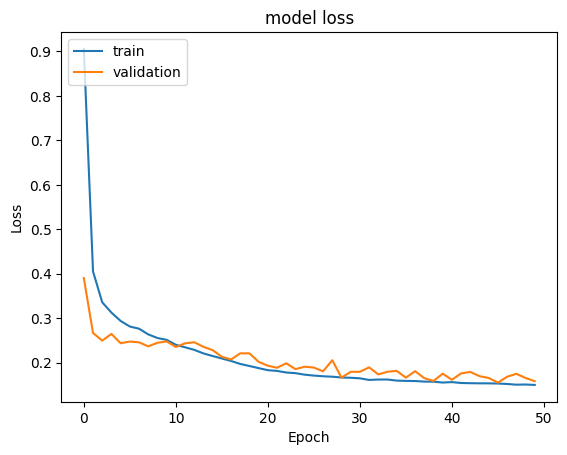

In [37]:
#Plotting Train Loss vs Validation Loss
plt.plot(history3.history['loss'])
plt.plot(history3.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

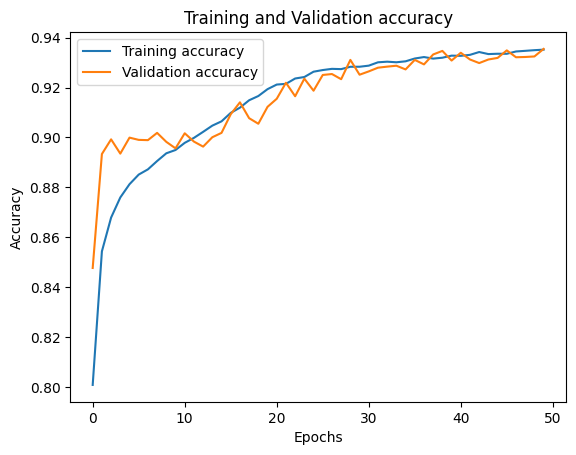

In [38]:
history_df = pd.DataFrame(history3.history)

plt.plot(history_df.loc[:, ['accuracy']], label='Training accuracy')
plt.plot(history_df.loc[:, ['val_accuracy']], label='Validation accuracy')

plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [39]:
val_accuracy = np.mean(history3.history['val_accuracy'])
print("\n%s: %.2f%%" % ('val_accuracy', val_accuracy*100))


val_accuracy: 91.65%


# Model 3 Increase batch size

In [66]:
from tensorflow.keras.layers import Dropout
import keras
model4=Sequential()
model4 = keras.Sequential([
    Dense(128, activation='relu', input_dim=input_dim),
    Dropout(0.4),  # ← Drop 40% of neurons randomly

    Dense(64, activation='relu'),
    Dropout(0.3),  # ← Drop 30% of neurons

    Dense(32, activation='relu'),
    Dropout(0.2),  # ← Drop 20% of neurons

    Dense(1, activation='sigmoid')
])

In [67]:
model4.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [71]:
history4=model4.fit(X, y,
          validation_split=0.2,
          epochs=50,
          batch_size=64,verbose=1)

Epoch 1/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8793 - loss: 0.2638 - val_accuracy: 0.9051 - val_loss: 0.2553
Epoch 2/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8777 - loss: 0.2609 - val_accuracy: 0.9122 - val_loss: 0.2112
Epoch 3/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8831 - loss: 0.2573 - val_accuracy: 0.9083 - val_loss: 0.2231
Epoch 4/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8873 - loss: 0.2534 - val_accuracy: 0.9100 - val_loss: 0.2418
Epoch 5/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8858 - loss: 0.2503 - val_accuracy: 0.9066 - val_loss: 0.2248
Epoch 6/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8885 - loss: 0.2502 - val_accuracy: 0.9112 - val_loss: 0.2169
Epoch 7/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8833 - loss: 0.2547 - val_accuracy: 0.9076 - val_loss: 0.2262
Epoch 8/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8900 - loss: 0.2427

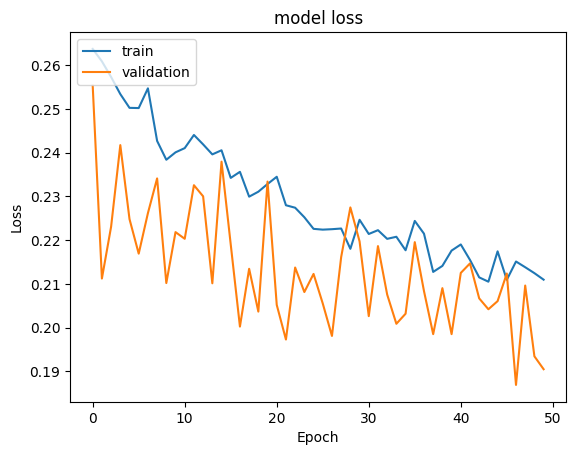

In [72]:
#Plotting Train Loss vs Validation Loss
plt.plot(history4.history['loss'])
plt.plot(history4.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

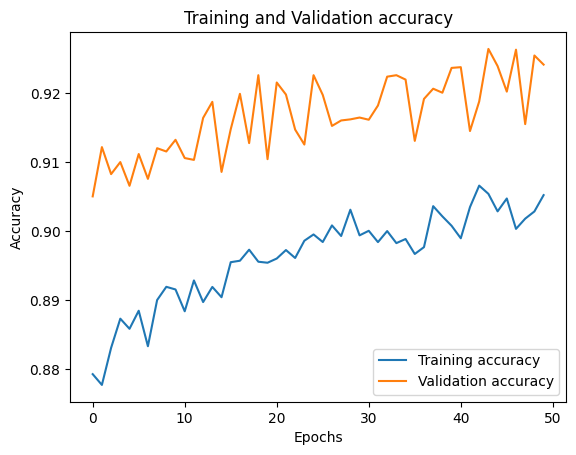

In [73]:
history4_df = pd.DataFrame(history4.history)

plt.plot(history4_df.loc[:, ['accuracy']], label='Training accuracy')
plt.plot(history4_df.loc[:, ['val_accuracy']], label='Validation accuracy')

plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [75]:
val_accuracy = np.mean(history4.history['val_accuracy'])
print("\n%s: %.2f%%" % ('val_accuracy', val_accuracy*100))


val_accuracy: 91.67%


# Model 5 Early stopping

In [80]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    mode='min'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.00001,
    mode='min'
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min'
)

In [83]:
model=Sequential()
model = Sequential([
    Dense(128, activation='relu', input_dim=input_dim),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [ ]:


model.compile(
    optimizer='Adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [86]:
history = model.fit(
    X, y,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/100
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7639 - loss: 0.6460 - val_accuracy: 0.8391 - val_loss: 0.3607 - learning_rate: 0.0010
Epoch 2/100
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8661 - loss: 0.3172 - val_accuracy: 0.8589 - val_loss: 0.3298 - learning_rate: 0.0010
Epoch 3/100
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8814 - loss: 0.2840 - val_accuracy: 0.8800 - val_loss: 0.2889 - learning_rate: 0.0010
Epoch 4/100
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8868 - loss: 0.2728 - val_accuracy: 0.8568 - val_loss: 0.3402 - learning_rate: 0.0010
Epoch 5/100
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8892 - loss: 0.2672 - val_accuracy: 0.8628 - val_loss: 0.3354 - learning_rate: 0.0010
Epoch 6/100
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8935 - loss: 0.2577 - val_accuracy: 0.8703 - val_loss: 0.3083 - learning_rate: 0.0010
Epoch 7/100
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8

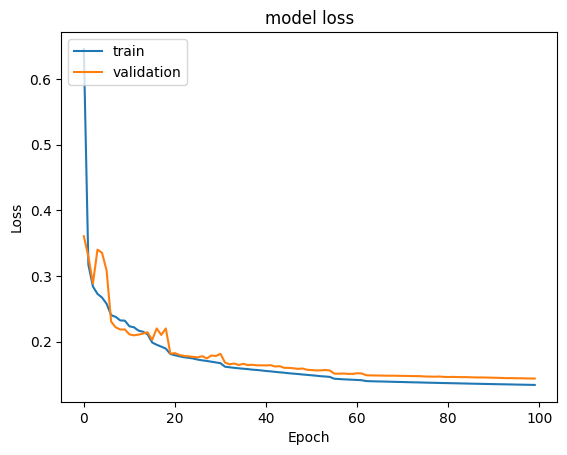

In [87]:

#Plotting Train Loss vs Validation Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

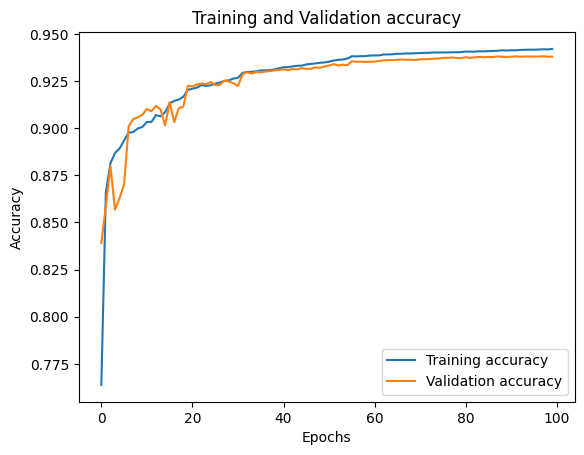

In [88]:
history_df = pd.DataFrame(history.history)

plt.plot(history_df.loc[:, ['accuracy']], label='Training accuracy')
plt.plot(history_df.loc[:, ['val_accuracy']], label='Validation accuracy')

plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [89]:
val_accuracy = np.mean(history.history['val_accuracy'])
print("\n%s: %.2f%%" % ('val_accuracy', val_accuracy*100))


val_accuracy: 92.56%


In [90]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

1113/1113 ━━━━━━━━━━━━━━━━━━━━ 1s 477us/step
